## Notebook for reading in baseline files, computing the 75th percentile temps, saving it out

In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
import xarray as xr

import warnings
warnings.filterwarnings('ignore')

In [8]:
#import sys
#!conda install --yes --prefix {sys.prefix} dask

# CanESM5 Baseline Threshold

In [2]:
file_path = '../../../Data/CMIP6/CanESM5/FixedCoords/baseline/*.nc'

# open without dask chunking and see if it crashes
#ds = xr.open_mfdataset(file_path) #, chunks={'time': 10})

# chunking but will likely have to load it all for quantile calc
ds = xr.open_mfdataset(file_path)#, chunks={'latitude': 10, 'longitude': 10})

In [3]:
ds.nbytes

359077016

In [4]:
ds

<xarray.Dataset> Size: 359MB
Dimensions:    (time: 10950, bnds: 2, lon: 128, lat: 64)
Coordinates:
  * time       (time) object 88kB 1961-01-01 12:00:00 ... 1990-12-31 12:00:00
  * lon        (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 175kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 2kB dask.array<chunksize=(128, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 1kB dask.array<chunksize=(64, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 359MB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
Attributes: (12/55)
    CDI:                         Climate Data Interface version 2.5.0 (https:...
    Conventions:                 CF-1.7 CMIP-6.2
    source:                      CanESM5 (2019): \naerosol: interactive\natmo...
    institution:                 Canadian Centre for Climate Modelling and An...
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    ...                          ...
    variable_id:                 tas
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0
    CDO:                         Climate Data Operators version 2.5.0 (https:...

In [5]:
np.unique(ds.time.dt.year.values)

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990])

In [6]:
ds['time'] = ds.indexes['time'].to_datetimeindex()

/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_82221/2135622427.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds['time'] = ds.indexes['time'].to_datetimeindex()
/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_82221/2135622427.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds['time'] = ds.indexes['time'].to_datetimeindex()


In [7]:
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds.load()

<xarray.Dataset> Size: 359MB
Dimensions:    (time: 10950, bnds: 2, lon: 128, lat: 64)
Coordinates:
  * time       (time) datetime64[ns] 88kB 1961-01-01T12:00:00 ... 1990-12-31T...
  * lon        (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 175kB 1961-01-01 00:00:00 ... 1991-01-01 0...
    lon_bnds   (lon, bnds) float64 2kB -181.4 -178.6 -178.6 ... 175.8 178.6
    lat_bnds   (lat, bnds) float64 1kB -90.0 -86.58 -86.58 ... 86.58 86.58 90.0
    tas        (time, lat, lon) float32 359MB 255.0 255.1 255.3 ... 237.4 237.4
Attributes: (12/55)
    CDI:                         Climate Data Interface version 2.5.0 (https:...
    Conventions:                 CF-1.7 CMIP-6.2
    source:                      CanESM5 (2019): \naerosol: interactive\natmo...
    institution:                 Canadian Centre for Climate Modelling and An...
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    ...                          ...
    variable_id:                 tas
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0
    CDO:                         Climate Data Operators version 2.5.0 (https:...

In [9]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds.tas.quantile(0.75, dim=('time'))
c_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
c_75.attrs["units"] = "K"
c_75

CPU times: user 1.33 s, sys: 133 ms, total: 1.46 s
Wall time: 1.52 s


<xarray.DataArray 'tas' (lat: 64, lon: 128)> Size: 66kB
array([[241.00008774, 241.21955109, 241.41810226, ..., 240.23161697,
        240.49313354, 240.73985672],
       [253.62111282, 254.04934311, 254.46363449, ..., 252.03792953,
        252.61951065, 253.14171219],
       [259.2420578 , 259.37942505, 259.56554413, ..., 259.14061737,
        259.20709991, 259.18371582],
       ...,
       [269.58872223, 269.48653412, 269.49753571, ..., 269.65457916,
        269.64626312, 269.58562469],
       [268.96660614, 268.94041443, 268.94393921, ..., 269.0973587 ,
        269.05638885, 268.99520111],
       [268.73603058, 268.69161224, 268.69973755, ..., 268.81445312,
        268.789505  , 268.75492859]], shape=(64, 128))
Coordinates:
  * lat       (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon       (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

### assuming everything looks good, then the next cell writes it out

In [10]:
#'../../../Data/ERA5-global/Baseline/*/*.nc'
c_75.to_netcdf("../../../Data/CMIP6/CanESM5/FixedCoords/baseline/computed_1961-1990-full_75th.nc")

In [11]:
! ls -l "../../../Data/CMIP6/CanESM5/FixedCoords/baseline/"

total 703768
-rw-r--r--@ 1 tedscott  staff      80360 May 20 16:29 computed_1961-1990-full_75th.nc
-rw-r--r--@ 1 tedscott  staff  360245996 May 20 16:04 tas_day_CanESM5_historical_r1i1p1f1_gn_19610101-19901231.nc


Text(0.5, 1.0, '75th Percentile T2m from 1961 - 1990 for CanESM5')

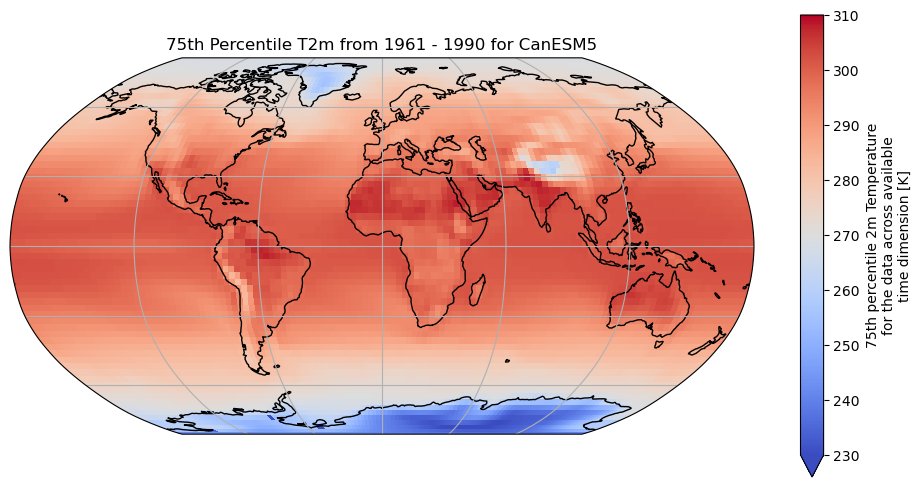

In [14]:
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot first index of SSTs
c_75.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=230,
    vmax=310, # define temp range for colorbar 230 to 310 K
    cmap="coolwarm"
)

plt.title("75th Percentile T2m from 1961 - 1990 for CanESM5")

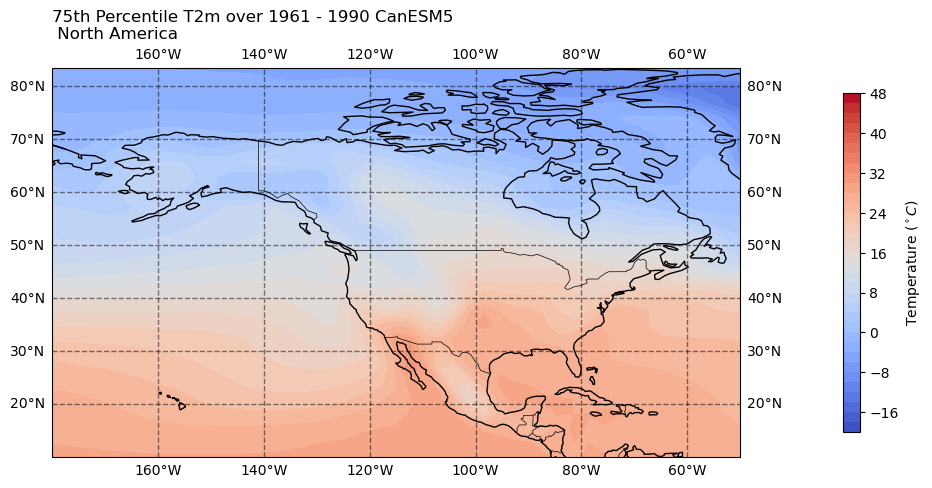

In [15]:
# make a north america map too

# try another way of plotting
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())  
ax.set_title("75th Percentile T2m over 1961 - 1990 CanESM5 \n North America", loc="left")
dataplot = ax.contourf(
    c_75.lon,
    c_75.lat,
    c_75-273.15,
    levels=np.arange(-20,50,2),
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.coolwarm,
)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
ax.set_extent((-180, -50, 10, 75))
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",
             shrink=0.55, pad=0.11
            )

# ** Still need to run for CESM2
- note could not change lat lon via cdo when running cdo -sellonlatbox,-180,180,-90,90 - got an error about time varying x & y so might need to do the conversion after getting the percentile calculation?

## open source files for 1961-1990

In [34]:
file_path1 = '../../../Data/CMIP6/CESM2/raw/tas_day_CESM2_historical_r1i1p1f1_gn_19610101-19851009.nc'
ds1 = xr.open_mfdataset(file_path1)

file_path2 = '../../../Data/CMIP6/CESM2/raw/tas_day_CESM2_historical_r1i1p1f1_gn_19851010-19901231.nc'
ds2 = xr.open_mfdataset(file_path2)

ds = ds1.merge(ds2)


In [35]:
ds.nbytes

2464279440

In [36]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (lat: 192, lon: 288, time: 10950, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 88kB 1961-01-01 00:00:00 ... 1990-12-31 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 2GB dask.array<chunksize=(636, 64, 96), meta=np.ndarray>
    time_bnds  (time, nbnd) object 175kB dask.array<chunksize=(1908, 2), meta=np.ndarray>
    lat_bnds   (time, lat, nbnd) float32 17MB dask.array<chunksize=(1908, 192, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float32 25MB dask.array<chunksize=(1908, 288, 2), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T22:26:44Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [37]:
np.unique(ds.time.dt.year.values)

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990])

In [38]:
ds['time'] = ds.indexes['time'].to_datetimeindex()
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (lat: 192, lon: 288, time: 10950, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 2GB dask.array<chunksize=(636, 64, 96), meta=np.ndarray>
    time_bnds  (time, nbnd) object 175kB dask.array<chunksize=(1908, 2), meta=np.ndarray>
    lat_bnds   (time, lat, nbnd) float32 17MB dask.array<chunksize=(1908, 192, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float32 25MB dask.array<chunksize=(1908, 288, 2), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T22:26:44Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

#### Adjust Lon to run from -180 to 180 instead of 0 to 360

In [39]:
# adjust longitude to run from -180 to 180
# solution from: https://stackoverflow.com/questions/53345442/about-changing-longitude-array-from-0-360-to-180-to-180-with-python-xarray
# save attributes so I can add them back later
lon_atrib = ds.coords['lon'].attrs  
lat_atrib = ds.coords['lat'].attrs
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
ds_fixed = ds.sortby(ds.lon)
ds_fixed

<xarray.Dataset> Size: 2GB
Dimensions:    (lat: 192, time: 10950, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * time       (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 2GB dask.array<chunksize=(636, 64, 96), meta=np.ndarray>
    time_bnds  (time, nbnd) object 175kB dask.array<chunksize=(1908, 2), meta=np.ndarray>
    lat_bnds   (time, lat, nbnd) float32 17MB dask.array<chunksize=(1908, 192, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float32 25MB dask.array<chunksize=(1908, 288, 2), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T22:26:44Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

#### Save out data with fixed time and longitude coords

In [40]:
file_path = '../../../Data/CMIP6/CESM2/FixedCoords/tas_day_CESM2_historical_r1i1p1f1_gn_19610101-19901231nc'

ds_fixed.to_netcdf(file_path)

### Calculate baseline 75th %

In [41]:
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds_fixed.load()

<xarray.Dataset> Size: 2GB
Dimensions:    (lat: 192, time: 10950, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * time       (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 2GB 247.7 247.7 247.7 ... 256.4 256.4
    time_bnds  (time, nbnd) object 175kB 1960-12-31 00:00:00 ... 1990-12-31 0...
    lat_bnds   (time, lat, nbnd) float32 17MB -90.0 -89.53 -89.53 ... 89.53 90.0
    lon_bnds   (time, lon, nbnd) float32 25MB 179.4 180.6 180.6 ... 178.1 179.4
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T22:26:44Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [42]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds_fixed.tas.quantile(0.75, dim=('time'))
c_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
c_75.attrs["units"] = "K"
c_75

CPU times: user 8.97 s, sys: 846 ms, total: 9.82 s
Wall time: 10.1 s


<xarray.DataArray 'tas' (lat: 192, lon: 288)> Size: 442kB
array([[234.80058289, 234.80616379, 234.80616379, ..., 234.75330353,
        234.75772476, 234.7748642 ],
       [234.26151276, 234.29961014, 234.3295517 , ..., 234.14857483,
        234.18935394, 234.22166824],
       [235.34697723, 235.40986633, 235.47353745, ..., 235.29081345,
        235.28463364, 235.32973862],
       ...,
       [270.73863983, 270.7377243 , 270.72985077, ..., 270.75177765,
        270.74143219, 270.73791504],
       [270.77828217, 270.77237701, 270.78060913, ..., 270.78917694,
        270.78504181, 270.78116608],
       [270.84149933, 270.84282684, 270.84532928, ..., 270.84636688,
        270.84644318, 270.84247589]], shape=(192, 288))
Coordinates:
  * lat       (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

### assuming everything looks good, then the next cell writes it out

In [43]:
#'../../../Data/ERA5-global/Baseline/*/*.nc'
c_75.to_netcdf("../../../Data/CMIP6/CESM2/FixedCoords/baseline/computed_1961-1990-full_75th.nc")

In [44]:
! ls -l "../../../Data/CMIP6/CESM2/FixedCoords/baseline/"

total 904
-rw-r--r--@ 1 tedscott  staff  460420 May 21 08:44 computed_1961-1990-full_75th.nc


Text(0.5, 1.0, '75th Percentile T2m from 1961 - 1990 for CESM2')

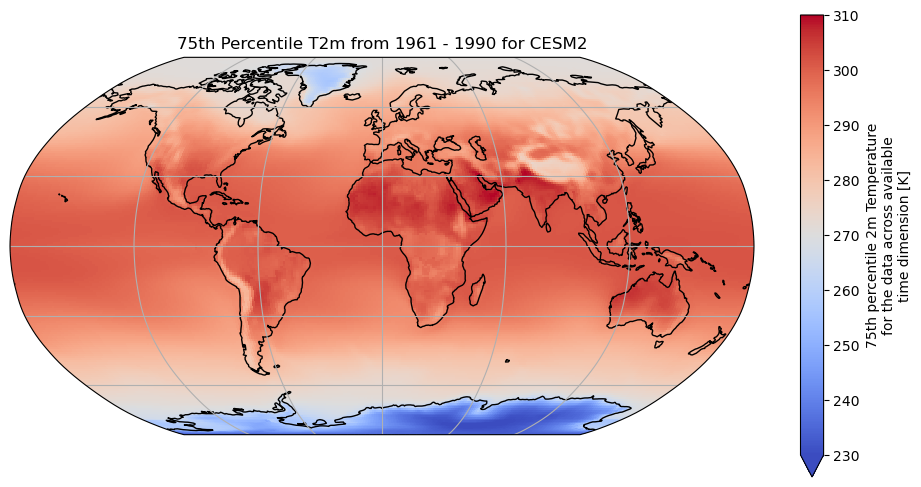

In [45]:
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot first index of SSTs
c_75.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=230,
    vmax=310, # define temp range for colorbar 230 to 310 K
    cmap="coolwarm"
)

plt.title("75th Percentile T2m from 1961 - 1990 for CESM2")

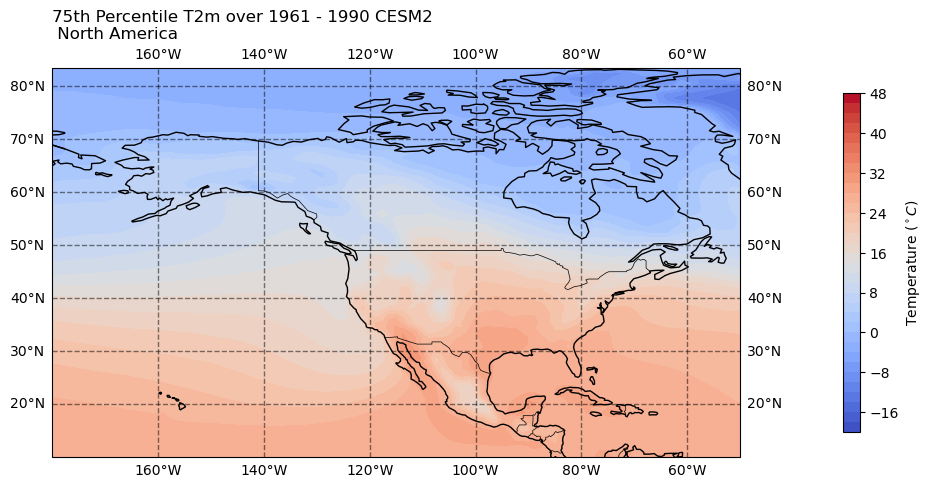

In [46]:
# make a north america map too

# try another way of plotting
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())  
ax.set_title("75th Percentile T2m over 1961 - 1990 CESM2 \n North America", loc="left")
dataplot = ax.contourf(
    c_75.lon,
    c_75.lat,
    c_75-273.15,
    levels=np.arange(-20,50,2),
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.coolwarm,
)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
ax.set_extent((-180, -50, 10, 75))
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",
             shrink=0.55, pad=0.11
            )

# GFDL-ESM2
- note could not change lat lon via cdo when running cdo -sellonlatbox,-180,180,-90,90 - got an error about time varying x & y so might need to do the conversion after getting the percentile calculation?

In [20]:
file_path1 = '../../../Data/CMIP6/GFDL-ESM4/Raw/tas_day_GFDL-ESM4_historical_r1i1p1f1_gr1_19610101-19870604.nc'
ds1 = xr.open_mfdataset(file_path1)

file_path2 = '../../../Data/CMIP6/GFDL-ESM4/Raw/tas_day_GFDL-ESM4_historical_r1i1p1f1_gr1_19870605-19901231.nc'
ds2 = xr.open_mfdataset(file_path2)

ds = ds1.merge(ds2)


In [21]:
ds.nbytes

2352852168

In [22]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (bnds: 2, lat: 180, lon: 288, time: 10950)
Coordinates:
  * bnds       (bnds) float64 16B 1.0 2.0
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * time       (time) object 88kB 1961-01-01 12:00:00 ... 1990-12-31 12:00:00
    height     float64 8B 2.0
Data variables:
    lat_bnds   (time, lat, bnds) float64 32MB dask.array<chunksize=(1305, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 50MB dask.array<chunksize=(1305, 288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 2GB dask.array<chunksize=(435, 60, 96), meta=np.ndarray>
    time_bnds  (time, bnds) object 175kB dask.array<chunksize=(1305, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               day
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/2bf6192a-1a73-4f08-af35-b0a38e0e0f2d
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [23]:
np.unique(ds.time.dt.year.values)

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990])

In [25]:
ds['time'] = ds.indexes['time'].to_datetimeindex()
ds

AttributeError: 'DatetimeIndex' object has no attribute 'to_datetimeindex'

#### Adjust Lon to run from -180 to 180 instead of 0 to 360

In [26]:
# adjust longitude to run from -180 to 180
# solution from: https://stackoverflow.com/questions/53345442/about-changing-longitude-array-from-0-360-to-180-to-180-with-python-xarray
# save attributes so I can add them back later
lon_atrib = ds.coords['lon'].attrs  
lat_atrib = ds.coords['lat'].attrs
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
ds_fixed = ds.sortby(ds.lon)
ds_fixed

<xarray.Dataset> Size: 2GB
Dimensions:    (bnds: 2, lat: 180, time: 10950, lon: 288)
Coordinates:
  * bnds       (bnds) float64 16B 1.0 2.0
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * time       (time) datetime64[ns] 88kB 1961-01-01T12:00:00 ... 1990-12-31T...
  * lon        (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
    height     float64 8B 2.0
Data variables:
    lat_bnds   (time, lat, bnds) float64 32MB dask.array<chunksize=(1305, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 50MB dask.array<chunksize=(1305, 288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 2GB dask.array<chunksize=(435, 60, 96), meta=np.ndarray>
    time_bnds  (time, bnds) object 175kB dask.array<chunksize=(1305, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               day
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/2bf6192a-1a73-4f08-af35-b0a38e0e0f2d
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

#### Save out data with fixed time and longitude coords

In [27]:
file_path = '../../../Data/CMIP6/GFDL-ESM4/FixedCoords/tas_day_GFDL-ESM4_historical_r1i1p1f1_gr1_19610101-19901231nc'

ds_fixed.to_netcdf(file_path)

### Calculate baseline 75th %

In [28]:
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds_fixed.load()

<xarray.Dataset> Size: 2GB
Dimensions:    (bnds: 2, lat: 180, time: 10950, lon: 288)
Coordinates:
  * bnds       (bnds) float64 16B 1.0 2.0
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * time       (time) datetime64[ns] 88kB 1961-01-01T12:00:00 ... 1990-12-31T...
  * lon        (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
    height     float64 8B 2.0
Data variables:
    lat_bnds   (time, lat, bnds) float64 32MB -90.0 -89.0 -89.0 ... 89.0 90.0
    lon_bnds   (time, lon, bnds) float64 50MB 180.0 181.2 181.2 ... 178.8 180.0
    tas        (time, lat, lon) float32 2GB 237.8 237.8 237.8 ... 246.9 246.9
    time_bnds  (time, bnds) object 175kB 1961-01-01 00:00:00 ... 1991-01-01 0...
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               day
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/2bf6192a-1a73-4f08-af35-b0a38e0e0f2d
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [29]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds_fixed.tas.quantile(0.75, dim=('time'))
c_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
c_75.attrs["units"] = "K"
c_75

CPU times: user 6.66 s, sys: 833 ms, total: 7.49 s
Wall time: 7.76 s


<xarray.DataArray 'tas' (lat: 180, lon: 288)> Size: 415kB
array([[232.26114655, 232.26734543, 232.284729  , ..., 232.22362518,
        232.23983383, 232.25183105],
       [233.77070999, 233.82932663, 233.89312363, ..., 233.58325577,
        233.6568985 , 233.71512985],
       [236.58597183, 236.75053787, 236.90254593, ..., 236.13204575,
        236.28129196, 236.44504166],
       ...,
       [270.2830658 , 270.28128815, 270.28505707, ..., 270.28268433,
        270.27661133, 270.28279877],
       [270.32775879, 270.31763458, 270.31313324, ..., 270.30745697,
        270.31652832, 270.32610321],
       [270.33882904, 270.33126831, 270.32994843, ..., 270.33628082,
        270.33679962, 270.34015656]], shape=(180, 288))
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

### assuming everything looks good, then the next cell writes it out

In [30]:
#'../../../Data/ERA5-global/Baseline/*/*.nc'
c_75.to_netcdf("../../../Data/CMIP6/GFDL-ESM4/FixedCoords/baseline/computed_1961-1990-full_75th.nc")

In [31]:
! ls -l "../../../Data/CMIP6/GFDL-ESM4/FixedCoords/baseline/"

total 848
-rw-r--r--@ 1 tedscott  staff  431687 May 20 16:48 computed_1961-1990-full_75th.nc


Text(0.5, 1.0, '75th Percentile T2m from 1961 - 1990 for GFDL-ESM4')

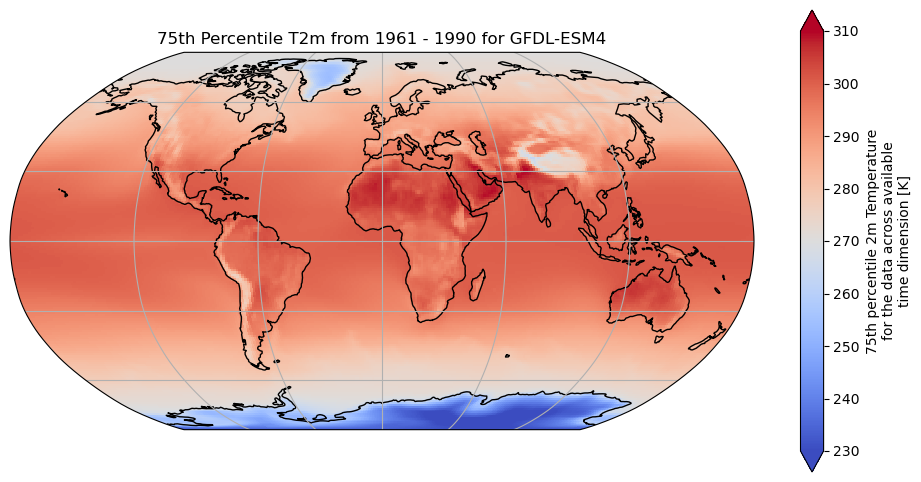

In [32]:
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot first index of SSTs
c_75.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=230,
    vmax=310, # define temp range for colorbar 230 to 310 K
    cmap="coolwarm"
)

plt.title("75th Percentile T2m from 1961 - 1990 for GFDL-ESM4")

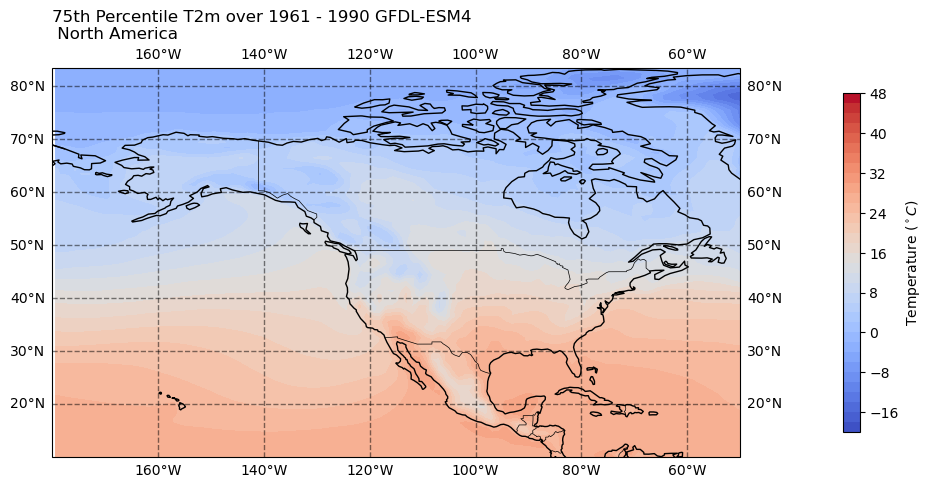

In [33]:
# make a north america map too

# try another way of plotting
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())  
ax.set_title("75th Percentile T2m over 1961 - 1990 GFDL-ESM4 \n North America", loc="left")
dataplot = ax.contourf(
    c_75.lon,
    c_75.lat,
    c_75-273.15,
    levels=np.arange(-20,50,2),
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.coolwarm,
)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
ax.set_extent((-180, -50, 10, 75))
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",
             shrink=0.55, pad=0.11
            )